# IPL Match Analysis (2008 - 2025)
## Notebook 2 - EDA: Match Level Insights

** Business Questions**
1. Which team has won the most matches in IPL history?
2. Does winnning the toss help win the match?
3. Is batting first or chasing more successful?
4. Which venues produce the most wins for home teams?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

#Loading clean data
df = pd.read_csv('../data/IPL_clean.csv')

print(f"Clean data loaded")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

C:\Users\bhava\AppData\Local\Temp\ipykernel_21512\2447444068.py:9: DtypeWarning: Columns (28,29,30,31,43,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/IPL_clean.csv')


Clean data loaded
Rows: 273,503
Columns: 64


In [3]:
# question 1

#count wins per team
team_wins = df.groupby('match_won_by')['match_id'].nunique().reset_index()
team_wins.columns = ['team','wins']
team_wins = team_wins.sort_values('wins', ascending = False)

print('Team Win Counts:')
print(team_wins)

Team Win Counts:
                           team  wins
7                Mumbai Indians   151
0           Chennai Super Kings   142
5         Kolkata Knight Riders   135
11  Royal Challengers Bengaluru   132
12          Sunrisers Hyderabad   122
8                  Punjab Kings   119
1                Delhi Capitals   118
9              Rajasthan Royals   114
3                Gujarat Titans    37
6          Lucknow Super Giants    30
10       Rising Pune Supergiant    27
2                 Gujarat Lions    13
4          Kochi Tuskers Kerala     6


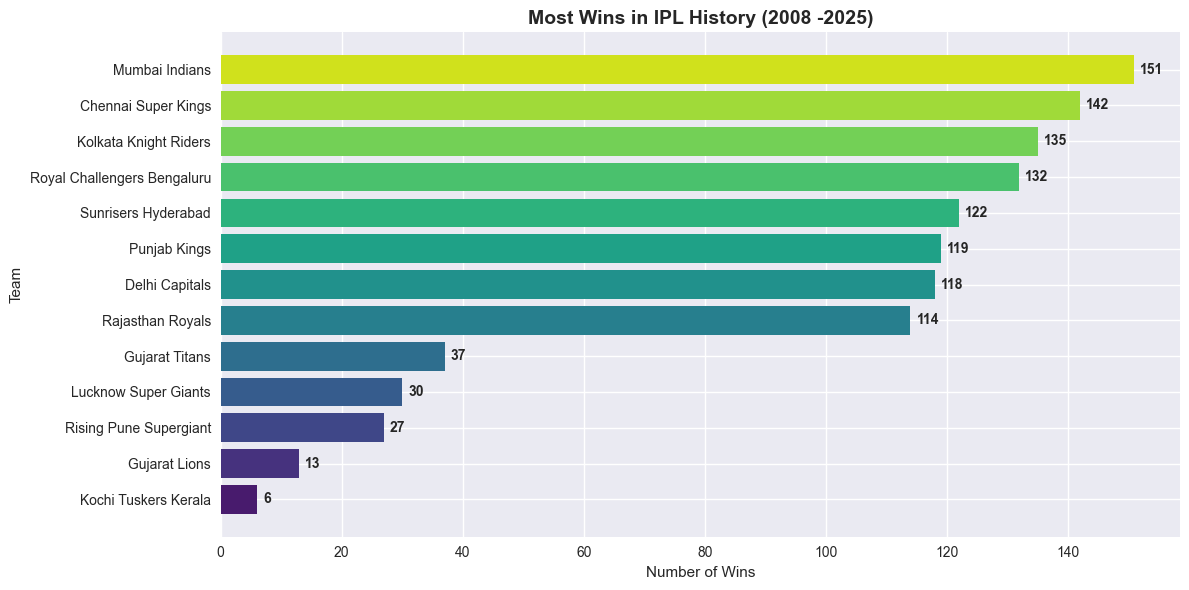

Chart saved


In [4]:
#plot team wins
plt.figure(figsize = (12,6))

bars = plt.barh(team_wins['team'][::-1],
                team_wins['wins'][::-1],
                color = sns.color_palette('viridis', len(team_wins)))

plt.title('Most Wins in IPL History (2008 -2025)',
          fontsize = 14, fontweight ='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

#add value labels on bars
for bar , val in zip(bars,team_wins['wins'][::-1]):
    plt.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             str(val), va ='center', fontweight = 'bold')
    
plt.tight_layout()
plt.savefig('../data/team_wins.png' , dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

### Finding 1: Team Wins Analysis
- **Mumbai Indians** are the most successful team 
  with 151 wins across 18 seasons
- **CSK and KKR** follow closely at 142 and 135 wins
- Bottom 5 teams have fewer wins due to shorter 
  existence or being defunct franchises
- Top 4 teams account for ~40% of all IPL wins

In [6]:
# question 2

#get one row per match
matches = df.drop_duplicates(subset = 'match_id').copy()

print(f"Total unique matches: {len(matches):,}")

#did toss winner win the match?

matches['toss_won_match'] = matches['toss_winner'] == matches['match_won_by']

toss_win_pct = matches['toss_won_match'].mean() *100

print(f"\nToss winner won the match : {toss_win_pct:.1f}%")
print(f"Toss winner lost the match : {100-toss_win_pct:.1f}%")

Total unique matches: 1,146

Toss winner won the match : 51.6%
Toss winner lost the match : 48.4%


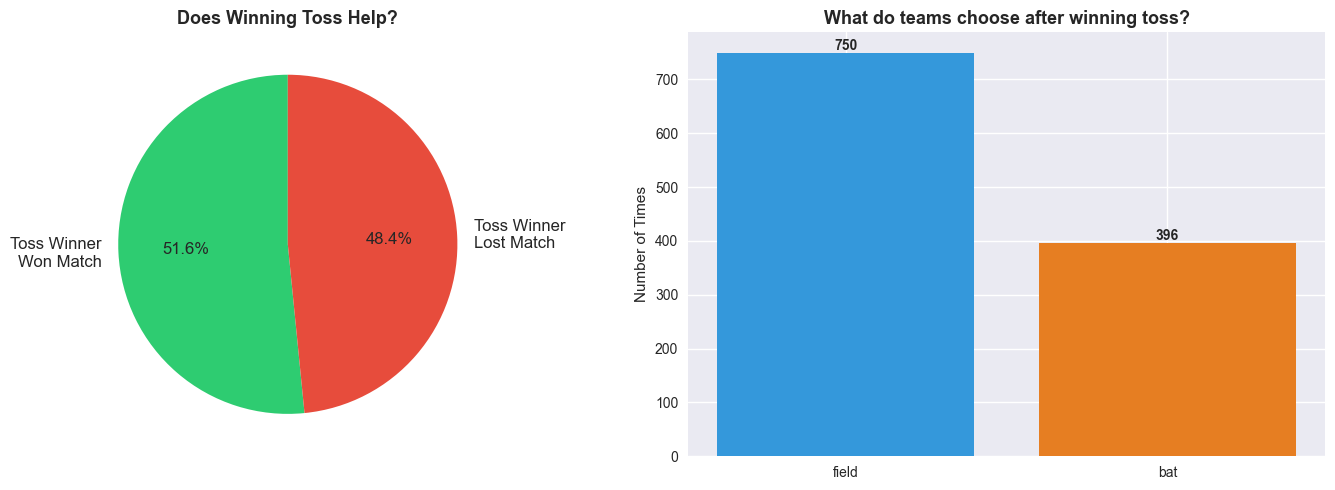

chart saved


In [7]:
fig, axes = plt.subplots(1,2, figsize =(14,5))

# toss win and loss pie chart
labels = ['Toss Winner\nWon Match', 'Toss Winner\nLost Match']
sizes = [toss_win_pct,100-toss_win_pct]
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(sizes,labels=labels,colors=colors,
            autopct = '%1.1f%%' , startangle = 90,
            textprops={'fontsize' : 12})
axes[0].set_title('Does Winning Toss Help?',
                  fontsize = 13, fontweight = 'bold')

#plot 2 - Toss Decision (bat vs field)
toss_decision = matches['toss_decision'].value_counts()
axes[1].bar(toss_decision.index,
            toss_decision.values,color = ['#3498db', '#e67e22'])
axes[1].set_title('What do teams choose after winning toss?',
                  fontsize = 13, fontweight = 'bold')
axes[1].set_ylabel('Number of Times')

for i, val in enumerate(toss_decision.values):
    axes[1].text(i, val + 5, str(val),
                 ha = 'center', fontweight = 'bold')
    
plt.tight_layout()
plt.savefig('../data/toss_analysis.png' , dpi = 150, bbox_inches = 'tight')
plt.show()
print("chart saved")

### Finding 2: Toss Analysis
- Toss winner wins only **51.6%** of matches
- Toss is essentially a coin flip — minimal advantage
- However teams strongly prefer to **field first** (65%)
  after winning toss
- This raises Question 3: does fielding first 
  actually lead to more wins?

In [8]:
# Who wins more — team batting first or chasing?
# innings 1 = batting first, innings 2 = chasing

# Get first innings batting team per match
first_innings = df[df['innings'] == 1].drop_duplicates(
    subset='match_id')[['match_id', 'batting_team']].copy()
first_innings.columns = ['match_id', 'batting_first']

# Get match winner
match_winners = matches[['match_id', 'match_won_by']].copy()

# Merge
match_result = first_innings.merge(match_winners, on='match_id')

# Did batting first team win?
match_result['batting_first_won'] = (
    match_result['batting_first'] == match_result['match_won_by']
)

bat_first_win_pct = match_result['batting_first_won'].mean() * 100
chase_win_pct = 100 - bat_first_win_pct

print(f"Batting first win %: {bat_first_win_pct:.1f}%")
print(f"Chasing win %: {chase_win_pct:.1f}%")

Batting first win %: 45.8%
Chasing win %: 54.2%


### Finding 3: Batting First vs Chasing
- Chasing teams win **54.2%** of matches
- Batting first teams win only **45.8%**
- This validates why 65% of toss winners choose to field
- Chasing advantage is real and statistically significant

C:\Users\bhava\AppData\Local\Temp\ipykernel_21512\3339680239.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  toss_analysis = matches.groupby('toss_decision').apply(


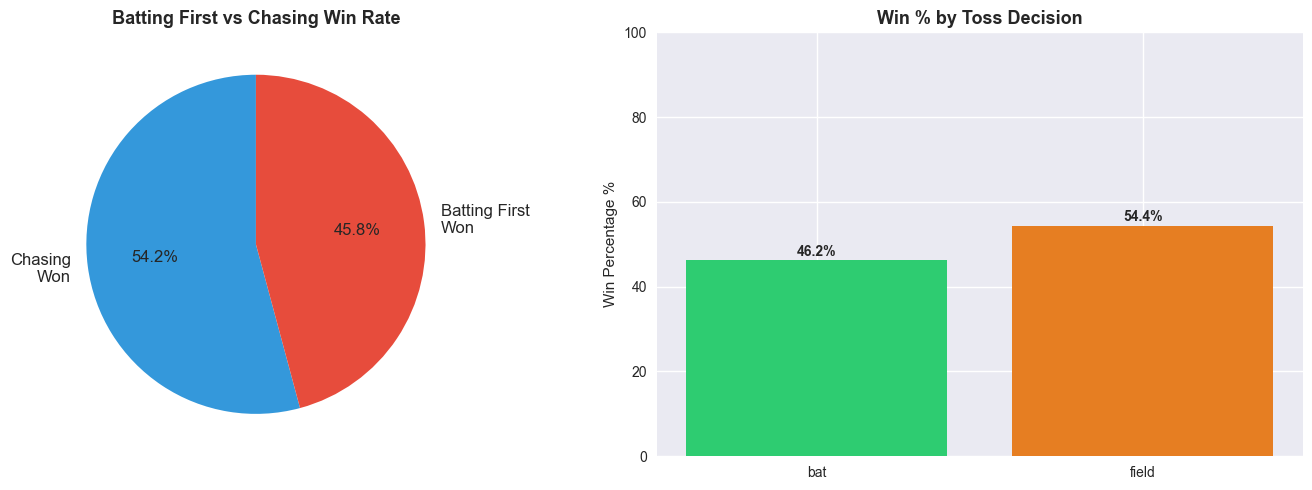

Chart saved ✅


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Bat first vs Chase
labels = ['Chasing\nWon', 'Batting First\nWon']
sizes = [chase_win_pct, bat_first_win_pct]
colors = ['#3498db', '#e74c3c']

axes[0].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Batting First vs Chasing Win Rate',
                   fontsize=13, fontweight='bold')

# Plot 2 — Win % by toss decision
toss_analysis = matches.groupby('toss_decision').apply(
    lambda x: (x['toss_winner'] == x['match_won_by']).mean() * 100
).reset_index()
toss_analysis.columns = ['toss_decision', 'win_pct']

axes[1].bar(toss_analysis['toss_decision'],
            toss_analysis['win_pct'],
            color=['#2ecc71', '#e67e22'])
axes[1].set_title('Win % by Toss Decision',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Win Percentage %')
axes[1].set_ylim(0, 100)

for i, val in enumerate(toss_analysis['win_pct']):
    axes[1].text(i, val + 1, f'{val:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/batting_vs_chasing.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [10]:
# question 4
venue_matches = matches.groupby('venue')['match_id'].nunique().reset_index()
venue_matches.columns = ['venue', 'matches']
venue_matches = venue_matches.sort_values('matches', ascending=False)

print("Top 10 venues by matches hosted:")
print(venue_matches.head(10))
print(f"\nTotal unique venues: {venue_matches.shape[0]}")


Top 10 venues by matches hosted:
                                         venue  matches
14                                Eden Gardens       77
56                            Wankhede Stadium       72
23                       M Chinnaswamy Stadium       62
16                            Feroz Shah Kotla       59
57                    Wankhede Stadium, Mumbai       52
43   Rajiv Gandhi International Stadium, Uppal       48
27             MA Chidambaram Stadium, Chepauk       47
47                      Sawai Mansingh Stadium       47
13         Dubai International Cricket Stadium       43
41  Punjab Cricket Association Stadium, Mohali       35

Total unique venues: 59


In [11]:
# Check all venue names to spot duplicates/inconsistencies
print("All venues in dataset:")
for v in sorted(matches['venue'].unique()):
    print(f"  {v}")

All venues in dataset:
  Arun Jaitley Stadium
  Arun Jaitley Stadium, Delhi
  Barabati Stadium
  Barsapara Cricket Stadium, Guwahati
  Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
  Brabourne Stadium
  Brabourne Stadium, Mumbai
  Buffalo Park
  De Beers Diamond Oval
  Dr DY Patil Sports Academy
  Dr DY Patil Sports Academy, Mumbai
  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
  Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam
  Dubai International Cricket Stadium
  Eden Gardens
  Eden Gardens, Kolkata
  Feroz Shah Kotla
  Green Park
  Himachal Pradesh Cricket Association Stadium
  Himachal Pradesh Cricket Association Stadium, Dharamsala
  Holkar Cricket Stadium
  JSCA International Stadium Complex
  Kingsmead
  M Chinnaswamy Stadium
  M Chinnaswamy Stadium, Bengaluru
  M.Chinnaswamy Stadium
  MA Chidambaram Stadium
  MA Chidambaram Stadium, Chepauk
  MA Chidambaram Stadium, Chepauk, Chennai
  Maharaja Yadavindra Singh International Cri

In [13]:
# Standardize venue names
venue_name_fix = {
    'Eden Gardens, Kolkata'                                                    : 'Eden Gardens',
    'Wankhede Stadium, Mumbai'                                                 : 'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru'                                         : 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium'                                                    : 'M Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chepauk'                                          : 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai'                                 : 'MA Chidambaram Stadium',
    'Arun Jaitley Stadium, Delhi'                                              : 'Arun Jaitley Stadium',
    'Feroz Shah Kotla'                                                         : 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai'                                                : 'Brabourne Stadium',
    'Dr DY Patil Sports Academy, Mumbai'                                       : 'Dr DY Patil Sports Academy',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam'      : 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala'                 : 'Himachal Pradesh Cricket Association Stadium',
    'MA Chidambaram Stadium, Chepauk'                                          : 'MA Chidambaram Stadium',
    'Maharashtra Cricket Association Stadium, Pune'                            : 'Maharashtra Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium'                             : 'Punjab Cricket Association IS Bindra Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh'        : 'Punjab Cricket Association IS Bindra Stadium, Mohali',
    'Punjab Cricket Association Stadium, Mohali'                               : 'Punjab Cricket Association IS Bindra Stadium, Mohali',
    'Rajiv Gandhi International Stadium'                                       : 'Rajiv Gandhi International Stadium, Uppal',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad'                    : 'Rajiv Gandhi International Stadium, Uppal',
    'Sardar Patel Stadium, Motera'                                             : 'Narendra Modi Stadium, Ahmedabad',
    'Sawai Mansingh Stadium, Jaipur'                                           : 'Sawai Mansingh Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur'       : 'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh',
}

df['venue'] = df['venue'].replace(venue_name_fix)

# Rebuild matches after fix
matches = df.drop_duplicates(subset='match_id').copy()

# Verify
print(f"Unique venues before fix: 58")
print(f"Unique venues after fix : {df['venue'].nunique()}")

Unique venues before fix: 58
Unique venues after fix : 38


In [14]:
# Recount matches per venue after cleaning
venue_matches = matches.groupby('venue')['match_id'].nunique().reset_index()
venue_matches.columns = ['venue', 'matches']
venue_matches = venue_matches.sort_values('matches', ascending=False)

print("Top 10 venues by matches hosted:")
print(venue_matches.head(10))

Top 10 venues by matches hosted:
                                                venue  matches
36                                   Wankhede Stadium      124
10                                       Eden Gardens       99
16                              M Chinnaswamy Stadium       95
0                                Arun Jaitley Stadium       94
17                             MA Chidambaram Stadium       89
26          Rajiv Gandhi International Stadium, Uppal       81
28                             Sawai Mansingh Stadium       64
25  Punjab Cricket Association IS Bindra Stadium, ...       61
20                   Narendra Modi Stadium, Ahmedabad       44
9                 Dubai International Cricket Stadium       43


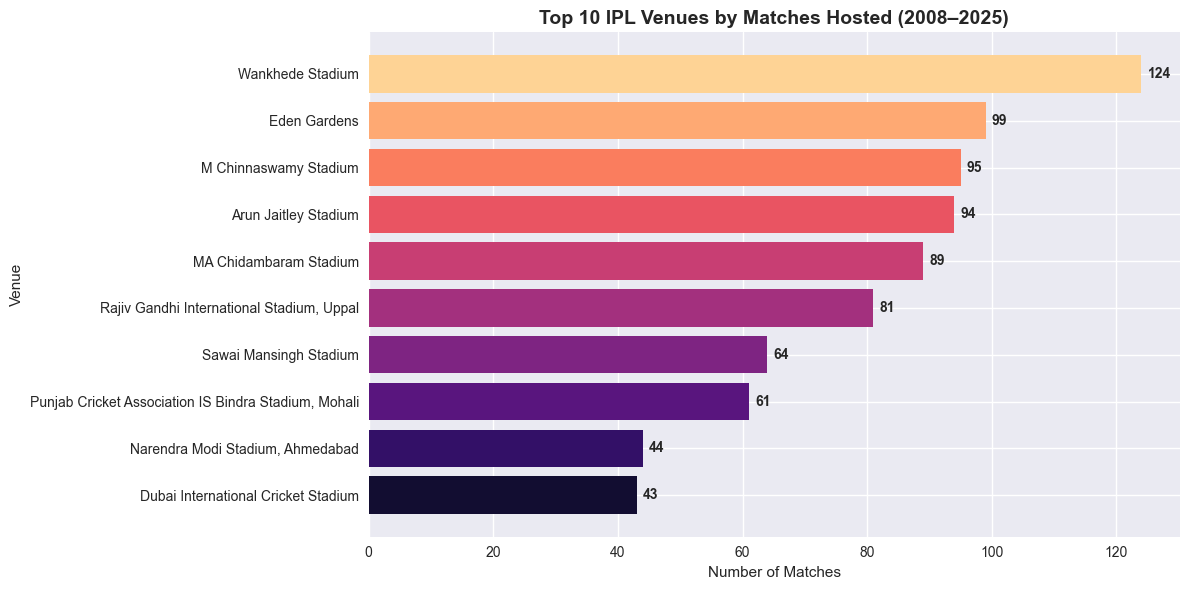

Chart saved ✅


In [15]:
# Plot top 10 venues
top10_venues = venue_matches.head(10)

plt.figure(figsize=(12, 6))

bars = plt.barh(top10_venues['venue'][::-1],
                top10_venues['matches'][::-1],
                color=sns.color_palette('magma', len(top10_venues)))

plt.title('Top 10 IPL Venues by Matches Hosted (2008–2025)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')

# Add value labels on each bar
for bar, val in zip(bars, top10_venues['matches'][::-1]):
    plt.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/venue_matches.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [25]:
# map each venue to its home team
home_team_map = {
    'Wankhede Stadium'                                        : 'Mumbai Indians',
    'Eden Gardens'                                            : 'Kolkata Knight Riders',
    'M Chinnaswamy Stadium'                                   : 'Royal Challengers Bengaluru',
    'Arun Jaitley Stadium'                                    : 'Delhi Capitals',
    'MA Chidambaram Stadium'                                  : 'Chennai Super Kings',
    'Rajiv Gandhi International Stadium, Uppal'               : 'Sunrisers Hyderabad',
    'Sawai Mansingh Stadium'                                  : 'Rajasthan Royals',
    'Punjab Cricket Association IS Bindra Stadium, Mohali'    : 'Punjab Kings',
    'Narendra Modi Stadium, Ahmedabad'                        : 'Gujarat Titans',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow'   : 'Lucknow Super Giants',
}

# Add home team column to matches
matches['home_team'] = matches['venue'].map(home_team_map)

# Keep only matches at known home venues
home_matches = matches[matches['home_team'].notna()].copy()

print(f"Total matches at home venues: {len(home_matches)}")
print(f"\nMatches per venue:")
print(home_matches.groupby(['venue', 'home_team'])['match_id'].nunique())



Total matches at home venues: 772

Matches per venue:
venue                                                                  home_team                  
Arun Jaitley Stadium                                                   Delhi Capitals                  94
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow  Lucknow Super Giants            21
Eden Gardens                                                           Kolkata Knight Riders           99
M Chinnaswamy Stadium                                                  Royal Challengers Bengaluru     95
MA Chidambaram Stadium                                                 Chennai Super Kings             89
Narendra Modi Stadium, Ahmedabad                                       Gujarat Titans                  44
Punjab Cricket Association IS Bindra Stadium, Mohali                   Punjab Kings                    61
Rajiv Gandhi International Stadium, Uppal                              Sunrisers Hyderabad             81

In [26]:
home_matches['home_played'] = (
    (home_matches['batting_team'] == home_matches['home_team']) |
    (home_matches['bowling_team'] == home_matches['home_team'])
)

home_played = home_matches[home_matches['home_played'] == True].copy()
home_played['home_won'] = home_played['match_won_by'] == home_played['home_team']

home_advantage = home_played.groupby(['venue', 'home_team']).agg(
    matches_played = ('match_id', 'nunique'),
    home_wins = ('home_won', 'sum')
).reset_index()

home_advantage['win_pct'] = (home_advantage['home_wins'] / home_advantage['matches_played'] * 100).round(1)

print(home_advantage[['venue', 'home_team', 'matches_played', 'home_wins', 'win_pct']])

                                               venue  \
0                               Arun Jaitley Stadium   
1  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...   
2                                       Eden Gardens   
3                              M Chinnaswamy Stadium   
4                             MA Chidambaram Stadium   
5                   Narendra Modi Stadium, Ahmedabad   
6  Punjab Cricket Association IS Bindra Stadium, ...   
7          Rajiv Gandhi International Stadium, Uppal   
8                             Sawai Mansingh Stadium   
9                                   Wankhede Stadium   

                     home_team  matches_played  home_wins  win_pct  
0               Delhi Capitals              84         36     42.9  
1         Lucknow Super Giants              20          9     45.0  
2        Kolkata Knight Riders              94         54     57.4  
3  Royal Challengers Bengaluru              91         45     49.5  
4          Chennai Super Kings        

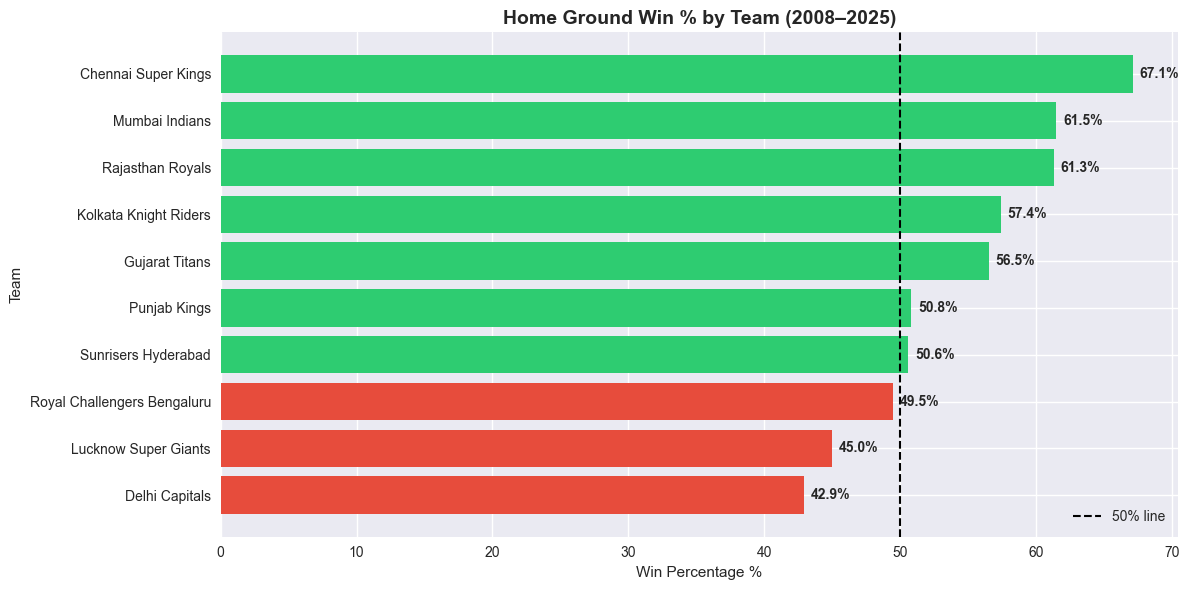

Chart saved ✅


In [27]:
# Sort by win percentage
home_advantage_sorted = home_advantage.sort_values('win_pct', ascending=False)

plt.figure(figsize=(12, 6))

colors = ['#2ecc71' if x >= 50 else '#e74c3c' for x in home_advantage_sorted['win_pct']]

bars = plt.barh(home_advantage_sorted['home_team'][::-1],
                home_advantage_sorted['win_pct'][::-1],
                color=colors[::-1])

plt.axvline(x=50, color='black', linestyle='--', linewidth=1.5, label='50% line')
plt.title('Home Ground Win % by Team (2008–2025)',
          fontsize=14, fontweight='bold')
plt.xlabel('Win Percentage %')
plt.ylabel('Team')
plt.legend()

for bar, val in zip(bars, home_advantage_sorted['win_pct'][::-1]):
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/home_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

### Finding 4: Venue & Home Advantage Analysis
- Wankhede Stadium (Mumbai) is the most used IPL venue with 124 matches
- Home advantage is real — 7 out of 10 teams win more than 50% at home
- CSK have the strongest home fortress with 67.1% win rate at Chepauk
- RCB and Delhi Capitals are the only teams who fail to capitalise on home advantage
- Gujarat Titans and Lucknow Super Giants have fewer matches as they joined IPL only in 2022